In [ ]:
# ── Cell 1 : Dependencies ──────────────────────────────────────────
!pip install pennylane pennylane-lightning-gpu umap-learn scipy -q

In [ ]:
# ── Cell 2 : Imports & Configuration ──────────────────────────────────
import os, sys, warnings, hashlib, time, tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load
import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found.', ImportWarning)

SEED = 42
np.random.seed(SEED)

DATASET_PATH = os.environ.get('DATASET_PATH', '/dataset_encoded_normalized1.csv')

N_LAYERS    = 2
ENTANGLE    = 'circular'
DE_MAXITER  = 20
DE_POPSZ    = 10
N_SPLITS_CV = 5

CACHE_DIR = 'cache_hybrid_pub'
os.makedirs(CACHE_DIR, exist_ok=True)
FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

WEIGHTS_FILE         = os.path.join(CACHE_DIR, 'best_weights.npy')
MODEL_CLASSICAL_FILE = os.path.join(CACHE_DIR, 'rf_classical.joblib')
MODEL_HYBRID_FILE    = os.path.join(CACHE_DIR, 'rf_hybrid.joblib')

print(f'PennyLane : {qml.version()}  |  Python : {sys.version.split()[0]}')
print(f'Dataset   : {DATASET_PATH}')

PennyLane : 0.44.1  |  Python : 3.13.11
Dataset   : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv


In [ ]:
# ── Cell 3 : Data Loading & 3-Way Split (70 / 15 / 15) ────────────────────
#
# FIX: MinMaxScaler fitted on X_train ONLY — applied to val/test via .transform().
#   AmplitudeEmbedding(normalize=True) still normalises per-sample to unit norm,
#   but MinMaxScaler ensures all features are in [0,1] before that normalization,
#   preventing large-magnitude features from dominating the amplitude encoding.

assert os.path.exists(DATASET_PATH), f'Dataset not found at {DATASET_PATH}'
df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)
N_FEATURES = X_raw.shape[1]
n_qubits   = N_FEATURES   # hybrid encoding: 1 qubit per feature

HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

X_tr_r, X_temp, Y_train, Y_temp = train_test_split(X_raw, Y, test_size=0.30, random_state=SEED)
X_val_r, X_test_r, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=SEED)

scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_tr_r)
X_val   = scaler.transform(X_val_r)
X_test  = scaler.transform(X_test_r)

print(f'Dataset  : {X_raw.shape[0]} × {N_FEATURES}  |  Hash: {HASH}')
print(f'Split    : Train={X_train.shape[0]}  Val={X_val.shape[0]}  Test={X_test.shape[0]}')
print(f'n_qubits : {n_qubits}  (1 qubit per feature, hybrid encoding)')

X_TRAIN_Q = os.path.join(CACHE_DIR, f'X_train_q_{HASH}.npy')
X_VAL_Q   = os.path.join(CACHE_DIR, f'X_val_q_{HASH}.npy')
X_TEST_Q  = os.path.join(CACHE_DIR, f'X_test_q_{HASH}.npy')

Dataset  : 13106 × 12  |  Hash: 8f057170
Split    : Train=9174  Val=1966  Test=1966
n_qubits : 12  (1 qubit per feature, hybrid encoding)


In [ ]:
# ── Cell 4 : Device ────────────────────────────────────────────────
try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU ready: {n_qubits} qubits')
except Exception as e:
    warnings.warn(f'GPU unavailable ({e}). Falling back to lightning.qubit.', RuntimeWarning)
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'
dev_cpu = qml.device('default.qubit', wires=n_qubits)
print(f'Active: {DEVICE_LABEL}')

GPU ready: 12 qubits
Active: lightning.gpu


In [ ]:
# ── Cell 5 : Hybrid Circuit Factory ────────────────────────────────────
#
# Hybrid encoding strategy:
#   1. AmplitudeEmbedding on first 2^amp_qubits features (uses amp_qubits wires)
#   2. RX(remaining features) on leftover wires
#   3. Parametric RY layers + CNOT entanglement on all n_qubits
#
# FIX: QNode built via factory (not at module level).

def build_hybrid_circuit(device, topology='circular'):
    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        n_feat = len(x)
        amp_qubits = min(n_qubits, max(1, int(np.ceil(np.log2(n_feat)))) if n_feat > 1 else 1)
        dim_amp    = 2 ** amp_qubits

        # Amplitude encoding on first amp_qubits wires
        amp_feat = (x[:dim_amp].tolist() if n_feat >= dim_amp
                    else x.tolist() + [0.0] * (dim_amp - n_feat))
        qml.AmplitudeEmbedding(features=amp_feat, wires=list(range(amp_qubits)), normalize=True)

        # RX rotation on remaining wires
        rotation_data = x[dim_amp:] if n_feat > dim_amp else np.array([])
        rot_wires     = list(range(amp_qubits, n_qubits))
        if rotation_data.size > 0 and rot_wires:
            for i, wire in enumerate(rot_wires):
                qml.RX(rotation_data[i % len(rotation_data)], wires=wire)
        elif rotation_data.size > 0:
            for i in range(n_qubits):
                qml.RX(rotation_data[i % len(rotation_data)], wires=i)

        # Parametric layers
        for layer in range(weights.shape[0]):
            for i in range(n_qubits):
                qml.RY(weights[layer, i], wires=i)
            if topology == 'linear':
                for i in range(n_qubits - 1): qml.CNOT(wires=[i, i+1])
            elif topology == 'circular':
                for i in range(n_qubits - 1): qml.CNOT(wires=[i, i+1])
                if n_qubits > 1: qml.CNOT(wires=[n_qubits-1, 0])
            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i+1, n_qubits): qml.CNOT(wires=[i, j])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    n = len(X_data)
    out = []
    for idx, xi in enumerate(X_data):
        out.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx+1) % max(1, n//10) == 0:
            print(f'  {idx+1}/{n}')
    return np.array(out)


circuit_default = build_hybrid_circuit(dev_gpu, topology=ENTANGLE)
print(f'Hybrid circuit ready | {n_qubits} qubits | topology={ENTANGLE} | N_LAYERS={N_LAYERS}')

Hybrid circuit ready | 12 qubits | topology=circular | N_LAYERS=2


In [ ]:
def _build_proxy_model():
    return RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1)

# ── Cell : COBYLA — Weight Optimization ──────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 200 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 200 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 200 samples, fixed seed ─────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 200, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

cobyla_history = []
call_counter   = {'n': 0}


def make_objective(circuit_fn, n_lay):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q  = quantum_feature_map(X_proxy, weights, circuit_fn)
        split    = int(0.8 * len(Y_proxy))
        X_sub    = X_q[:split];    X_val_p = X_q[split:]
        Y_sub    = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        cobyla_history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    cobyla_history.clear()
    obj = make_objective(circuit_fn, n_lay)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay*n_qubits} params')
    print(f'  Proxy : 200 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2*np.pi, 2*np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


print('Optimizing circuit weights with COBYLA (200 proxy samples)...')
best_weights = run_cobyla(circuit_default, N_LAYERS, WEIGHTS_FILE)

if cobyla_history:
    np.save(os.path.join(CACHE_DIR, 'cobyla_convergence.npy'), np.array(cobyla_history))


Optimizing circuit weights with COBYLA (200 proxy samples)...
  COBYLA: 2 layers x 12 qubits = 24 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.016127
  [COBYLA call    2]  val MSE = 0.012424
  [COBYLA call    3]  val MSE = 0.016569
  [COBYLA call   50]  val MSE = 0.006889
  [COBYLA call  100]  val MSE = 0.006175
  [COBYLA call  150]  val MSE = 0.006066
  Restart 1/3 — val MSE = 0.006066
  [COBYLA call  200]  val MSE = 0.013243
  [COBYLA call  250]  val MSE = 0.009874
  [COBYLA call  300]  val MSE = 0.005335
  [COBYLA call  350]  val MSE = 0.005121
  Restart 2/3 — val MSE = 0.005106
  [COBYLA call  400]  val MSE = 0.008098
  [COBYLA call  450]  val MSE = 0.006753
  [COBYLA call  500]  val MSE = 0.006632
  [COBYLA call  550]  val MSE = 0.005971
  Restart 3/3 — val MSE = 0.005971
  Done in 32.0 min | best val MSE = 0.005106


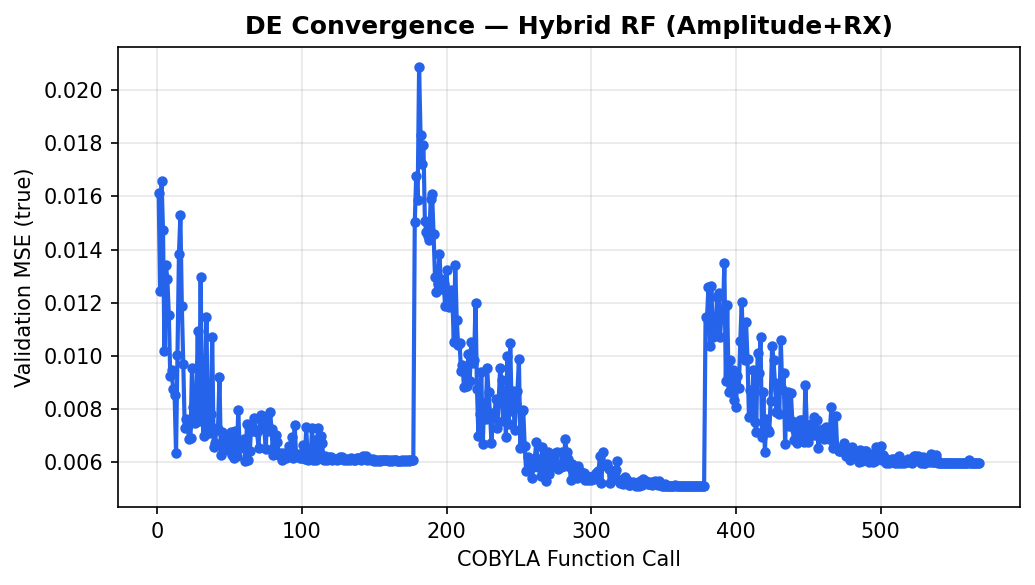

In [ ]:
# ── Cell 7 : DE Convergence Plot ───────────────────────────────────────
conv_f = os.path.join(CACHE_DIR, 'cobyla_convergence.npy')
if os.path.exists(conv_f):
    hist = np.load(conv_f)
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(hist[:,0], hist[:,1], color='#2563EB', lw=2, marker='o', ms=4)
    ax.set_xlabel('COBYLA Function Call'); ax.set_ylabel('Validation MSE (true)')
    ax.set_title('DE Convergence — Hybrid RF (Amplitude+RX)', fontweight='bold')
    ax.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No convergence history (weights from cache).')

In [ ]:
# ── Cell 8 : Quantum Feature Computation ─────────────────────────────────
if os.path.exists(X_TRAIN_Q) and os.path.exists(X_VAL_Q) and os.path.exists(X_TEST_Q):
    print('Loading from cache...')
    X_train_q = np.load(X_TRAIN_Q)
    X_val_q   = np.load(X_VAL_Q)
    X_test_q  = np.load(X_TEST_Q)
else:
    print('Computing quantum features...')
    X_train_q = quantum_feature_map(X_train, best_weights, circuit_default, verbose=True)
    np.save(X_TRAIN_Q, X_train_q)
    X_val_q = quantum_feature_map(X_val, best_weights, circuit_default, verbose=True)
    np.save(X_VAL_Q, X_val_q)
    X_test_q = quantum_feature_map(X_test, best_weights, circuit_default, verbose=True)
    np.save(X_TEST_Q, X_test_q)
print(f'Shapes — train_q:{X_train_q.shape}  val_q:{X_val_q.shape}  test_q:{X_test_q.shape}')

Computing quantum features...
  917/9174
  1834/9174
  2751/9174
  3668/9174
  4585/9174
  5502/9174
  6419/9174
  7336/9174
  8253/9174
  9170/9174
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  1372/1966
  1568/1966
  1764/1966
  1960/1966
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  1372/1966
  1568/1966
  1764/1966
  1960/1966
Shapes — train_q:(9174, 12)  val_q:(1966, 12)  test_q:(1966, 12)


In [ ]:
# ── Cell 9 : Model Training ─────────────────────────────────────────────
RF_PARAMS = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}

def tune_rf(Xtr, Ytr, label):
    print(f'  Tuning {label} (20 iter, {N_SPLITS_CV}-fold CV)...')
    s = RandomizedSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                           RF_PARAMS, n_iter=20, scoring='neg_mean_squared_error',
                           cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0)
    s.fit(Xtr, Ytr)
    print(f'  Best: {s.best_params_}  |  CV MSE: {-s.best_score_:.4f}')
    return s.best_estimator_

print('\n── Classical RF ──')
rf_classical = (load(MODEL_CLASSICAL_FILE) if os.path.exists(MODEL_CLASSICAL_FILE)
                else tune_rf(X_train, Y_train, 'Classical RF'))
if not os.path.exists(MODEL_CLASSICAL_FILE): dump(rf_classical, MODEL_CLASSICAL_FILE)

print('\n── Hybrid RF ──')
rf_hybrid = (load(MODEL_HYBRID_FILE) if os.path.exists(MODEL_HYBRID_FILE)
             else tune_rf(X_train_q, Y_train, 'Hybrid RF'))
if not os.path.exists(MODEL_HYBRID_FILE): dump(rf_hybrid, MODEL_HYBRID_FILE)


── Classical RF ──
  Tuning Classical RF (20 iter, 5-fold CV)...
  Best: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}  |  CV MSE: 0.0019

── Hybrid RF ──
  Tuning Hybrid RF (20 iter, 5-fold CV)...
  Best: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}  |  CV MSE: 0.0072


In [ ]:
# ── Cell 10 : 5-Fold Cross-Validation ──────────────────────────────────
X_tv   = np.vstack([X_train,   X_val])
X_tv_q = np.vstack([X_train_q, X_val_q])
Y_tv   = np.concatenate([Y_train, Y_val])

kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
cv_scores = {'classical': [], 'hybrid': []}

for fold, (ti, vi) in enumerate(kf.split(X_tv)):
    for key, X_all, params in [
        ('classical', X_tv,   rf_classical.get_params()),
        ('hybrid',    X_tv_q, rf_hybrid.get_params())
    ]:
        m = RandomForestRegressor(**params)
        m.fit(X_all[ti], Y_tv[ti])
        p = m.predict(X_all[vi])
        pr, _ = pearsonr(Y_tv[vi], p)
        sr, _ = spearmanr(Y_tv[vi], p)
        cv_scores[key].append({'mse': mean_squared_error(Y_tv[vi], p),
                                'mae': mean_absolute_error(Y_tv[vi], p),
                                'r2': r2_score(Y_tv[vi], p),
                                'pearson': pr, 'spearman': sr})
    print(f'  Fold {fold+1}/{N_SPLITS_CV}  '
          f'Classical R²={cv_scores["classical"][-1]["r2"]:.4f}  '
          f'Hybrid R²={cv_scores["hybrid"][-1]["r2"]:.4f}')

def cv_summary(scores, label):
    keys = ['mse','mae','r2','pearson','spearman']
    return pd.Series({k: f"{np.mean([s[k] for s in scores]):.4f} ± {np.std([s[k] for s in scores]):.4f}"
                      for k in keys}, name=label)

cv_df = pd.DataFrame([cv_summary(cv_scores['classical'], 'Classical RF'),
                      cv_summary(cv_scores['hybrid'],    'Hybrid RF')])
print(f'\n── {N_SPLITS_CV}-Fold CV ──')
print(cv_df.to_string())

  Fold 1/5  Classical R²=0.9051  Hybrid R²=0.5787
  Fold 2/5  Classical R²=0.9235  Hybrid R²=0.6386
  Fold 3/5  Classical R²=0.8780  Hybrid R²=0.5739
  Fold 4/5  Classical R²=0.9044  Hybrid R²=0.5903
  Fold 5/5  Classical R²=0.9075  Hybrid R²=0.6093

── 5-Fold CV ──
                          mse              mae               r2          pearson         spearman
Classical RF  0.0017 ± 0.0002  0.0251 ± 0.0008  0.9037 ± 0.0146  0.9514 ± 0.0076  0.9459 ± 0.0062
Hybrid RF     0.0071 ± 0.0003  0.0597 ± 0.0010  0.5981 ± 0.0236  0.7751 ± 0.0160  0.7545 ± 0.0146


In [ ]:
# ── Cell 11 : Wilcoxon Test ────────────────────────────────────────────
r2_c  = [s['r2']  for s in cv_scores['classical']]
r2_h  = [s['r2']  for s in cv_scores['hybrid']]
mse_c = [s['mse'] for s in cv_scores['classical']]
mse_h = [s['mse'] for s in cv_scores['hybrid']]
stat_r2,  p_r2  = wilcoxon(r2_h,  r2_c,  alternative='greater')
stat_mse, p_mse = wilcoxon(mse_c, mse_h, alternative='greater')
print(f'Wilcoxon R²  : stat={stat_r2:.3f}  p={p_r2:.4f}  {"significant" if p_r2<0.05 else "not significant"}')
print(f'Wilcoxon MSE : stat={stat_mse:.3f}  p={p_mse:.4f}  {"significant" if p_mse<0.05 else "not significant"}')

Wilcoxon R²  : stat=0.000  p=1.0000  not significant
Wilcoxon MSE : stat=0.000  p=1.0000  not significant


In [ ]:
# ── Cell 12 : Final Holdout Evaluation ──────────────────────────────────
def evaluate(model, Xte, Yte, label):
    tracemalloc.start()
    t0 = time.time(); Yp = model.predict(Xte); elapsed = time.time()-t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    pr,_ = pearsonr(Yte, Yp); sr,_ = spearmanr(Yte, Yp)
    return {'Model': label,
            'MSE': mean_squared_error(Yte, Yp),
            'RMSE': np.sqrt(mean_squared_error(Yte, Yp)),
            'MAE': mean_absolute_error(Yte, Yp),
            'R2': r2_score(Yte, Yp),
            'Pearson r': pr, 'Spearman rho': sr,
            'Time (s)': elapsed, 'Memory (MB)': peak/1024**2, '_pred': Yp}

rc = evaluate(rf_classical, X_test,   Y_test, 'Classical RF')
rh = evaluate(rf_hybrid,    X_test_q, Y_test, 'Hybrid RF')
preds = {'Classical RF': rc.pop('_pred'), 'Hybrid RF': rh.pop('_pred')}
results_df = pd.DataFrame([rc, rh]).set_index('Model')
print('\n── Test Set Results ──')
print(results_df[['MSE','RMSE','MAE','R2','Pearson r','Spearman rho', 'Time (s)', 'Memory (MB)']].round(4).to_string())


── Test Set Results ──
                 MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)
Model                                                                                       
Classical RF  0.0016  0.0406  0.0253  0.9139     0.9565        0.9436    0.2825       0.4096
Hybrid RF     0.0075  0.0867  0.0614  0.6068     0.7830        0.7581    0.2130       0.3933


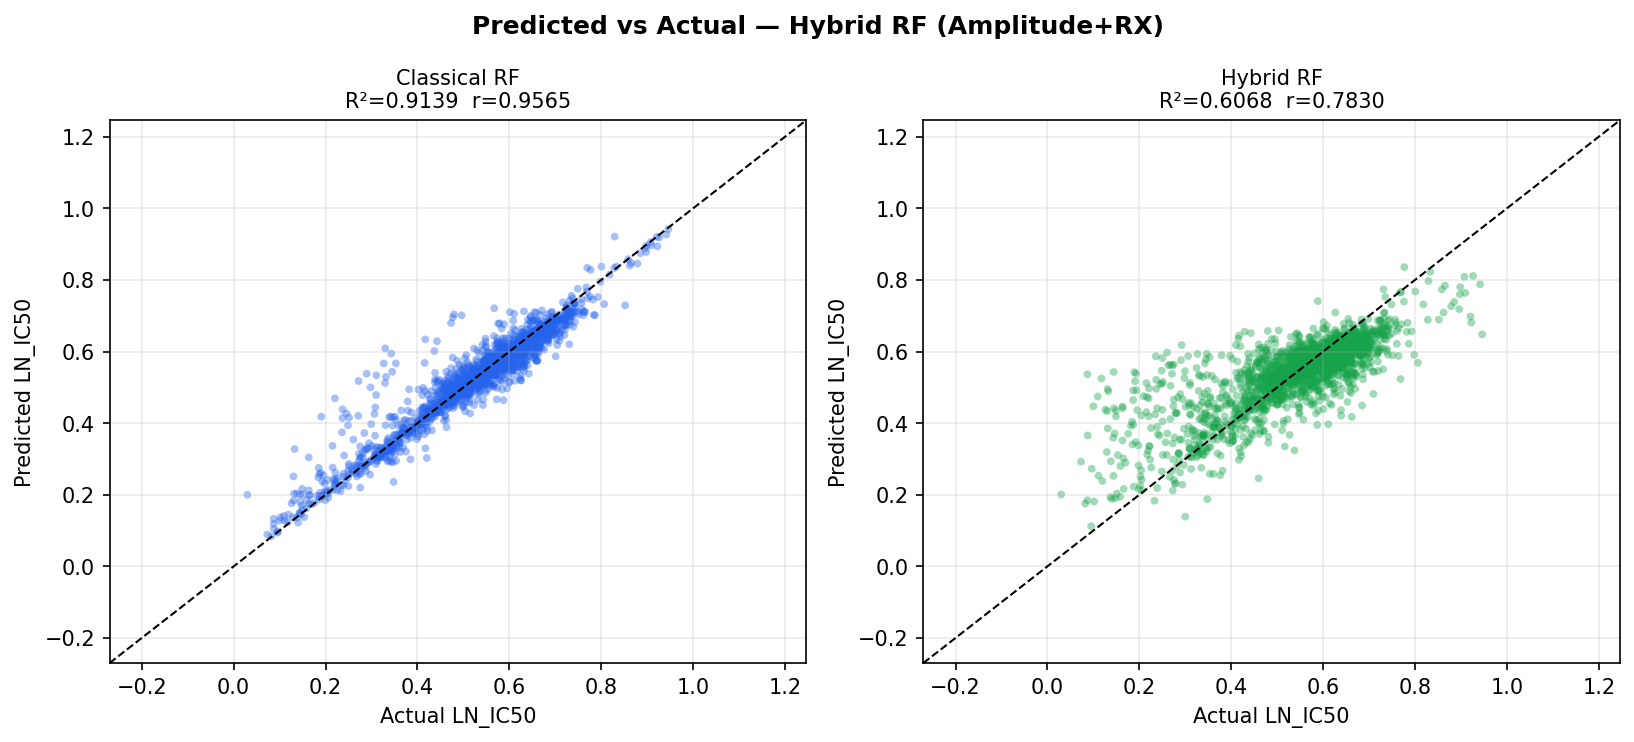

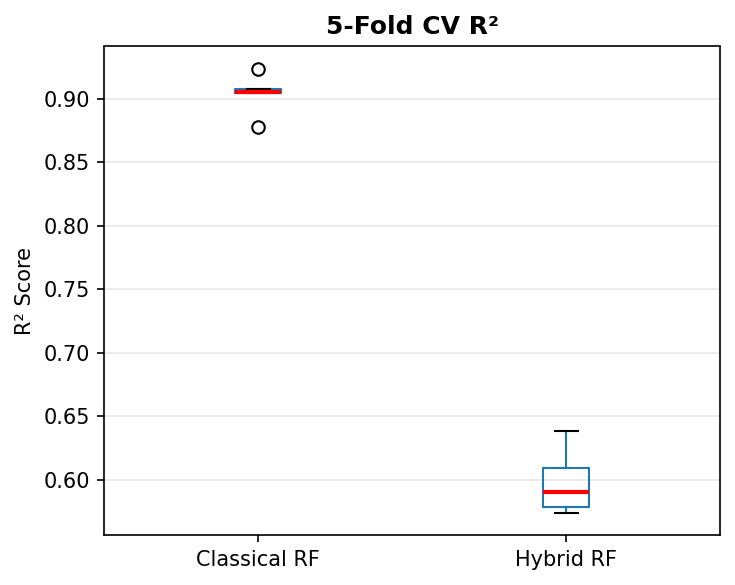

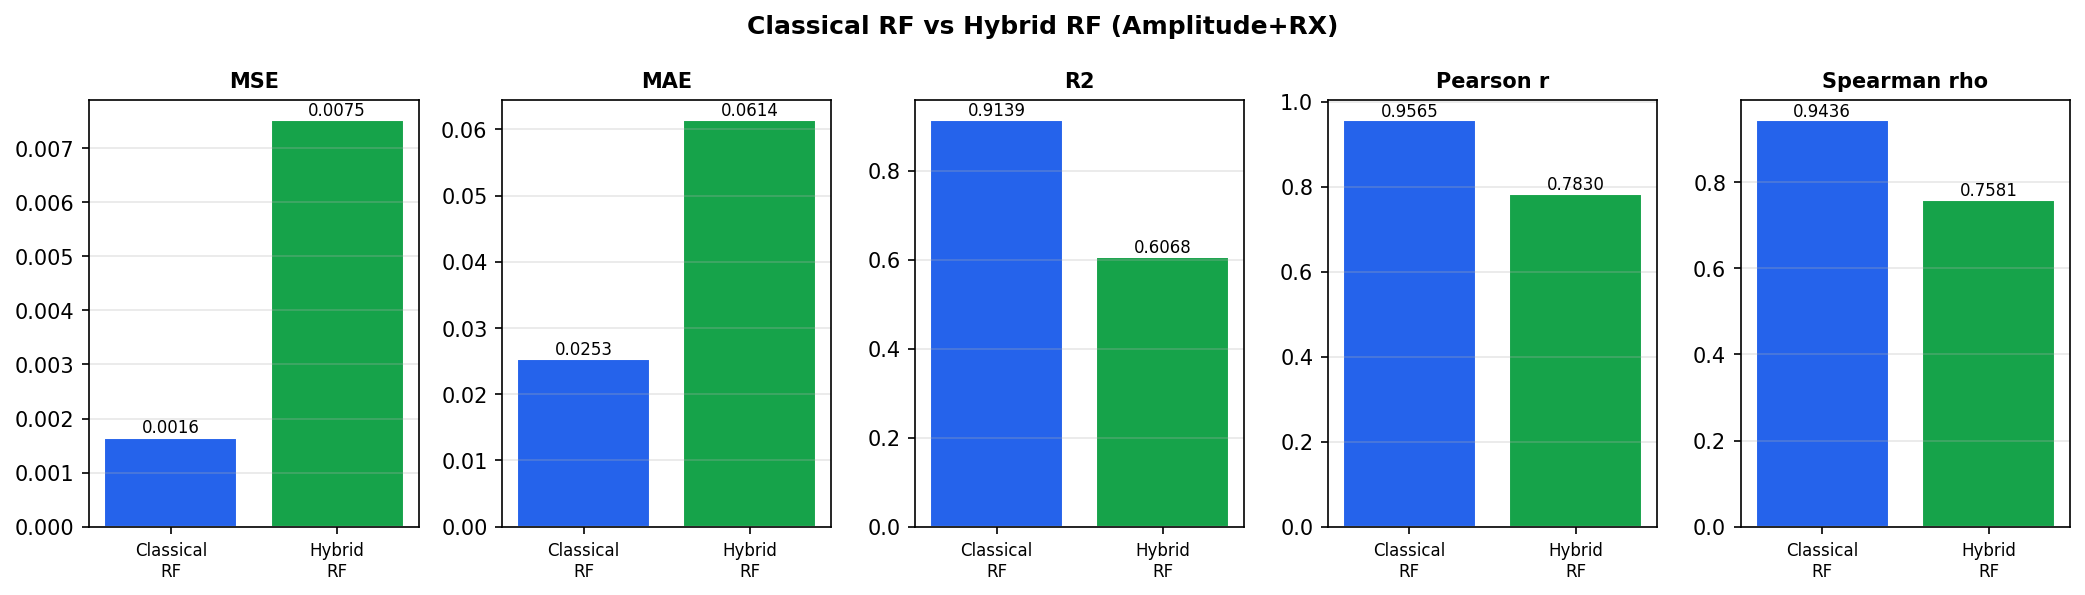

Figures saved to /home/host1-vm4/cache_hybrid_pub/figures


In [ ]:
# ── Cell 13 : Publication Figures ───────────────────────────────────────
PAL = {'Classical RF': '#2563EB', 'Hybrid RF': '#16A34A'}

# Pred vs actual
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=150)
for ax, (label, color) in zip(axes, PAL.items()):
    yp = preds[label]
    lims = [min(Y_test.min(), yp.min())-.3, max(Y_test.max(), yp.max())+.3]
    ax.scatter(Y_test, yp, alpha=0.4, s=14, color=color, edgecolors='none')
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{label}\nR²={results_df.loc[label,"R2"]:.4f}  r={results_df.loc[label,"Pearson r"]:.4f}', fontsize=10)
    ax.set_xlabel('Actual LN_IC50'); ax.set_ylabel('Predicted LN_IC50')
    ax.grid(True, alpha=0.25)
plt.suptitle('Predicted vs Actual — Hybrid RF (Amplitude+RX)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_pred_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# CV boxplot
cv_plot = pd.DataFrame({'Classical RF': r2_c, 'Hybrid RF': r2_h})
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
cv_plot.boxplot(ax=ax, grid=False, medianprops=dict(color='red', lw=2))
ax.set_ylabel('R² Score'); ax.set_title(f'{N_SPLITS_CV}-Fold CV R²', fontweight='bold')
ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_cv_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# Metrics bar
metrics_bar = ['MSE','MAE','R2','Pearson r','Spearman rho']
fig, axes = plt.subplots(1, 5, figsize=(14, 4), dpi=150)
labels = list(PAL.keys()); colors = list(PAL.values())
for ax, m in zip(axes, metrics_bar):
    vals = [results_df.loc[l, m] for l in labels]
    bars = ax.bar(range(2), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(2)); ax.set_xticklabels([l.replace(' ','\n') for l in labels], fontsize=8)
    ax.set_title(m, fontweight='bold', fontsize=10); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003*abs(max(vals)-min(vals)),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Classical RF vs Hybrid RF (Amplitude+RX)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Figures saved to {os.path.abspath(FIGDIR)}')

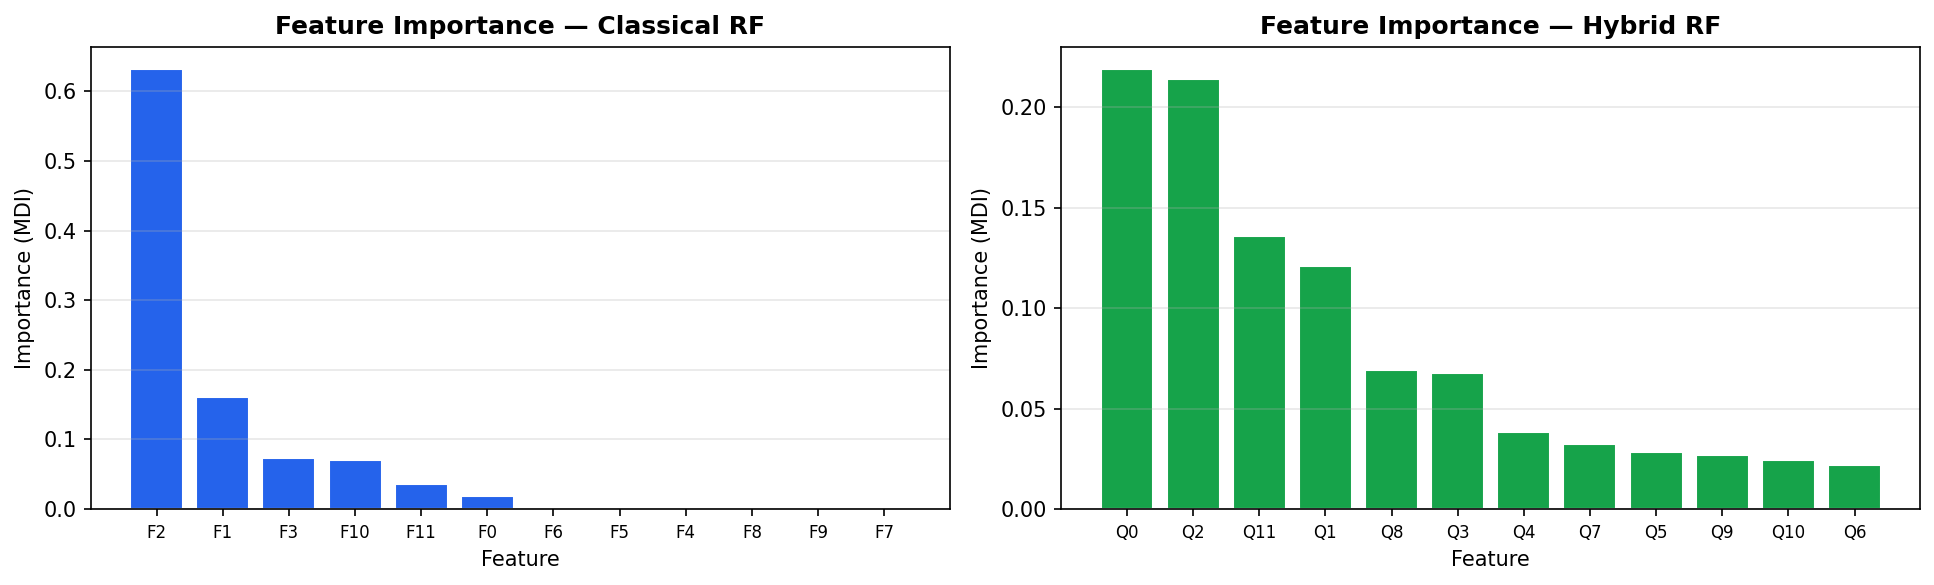

In [ ]:
# ── Cell 14 : Feature Importance ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=150)
for ax, (label, model, fnames) in zip(axes, [
    ('Classical RF', rf_classical, [f'F{i}' for i in range(N_FEATURES)]),
    ('Hybrid RF',    rf_hybrid,    [f'Q{i}' for i in range(n_qubits)])
]):
    imp = model.feature_importances_; idx = np.argsort(imp)[::-1]
    ax.bar(range(len(imp)), imp[idx], color=PAL[label], edgecolor='white')
    ax.set_xticks(range(len(imp))); ax.set_xticklabels([fnames[i] for i in idx], fontsize=8)
    ax.set_xlabel('Feature'); ax.set_ylabel('Importance (MDI)')
    ax.set_title(f'Feature Importance — {label}', fontweight='bold'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig5_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


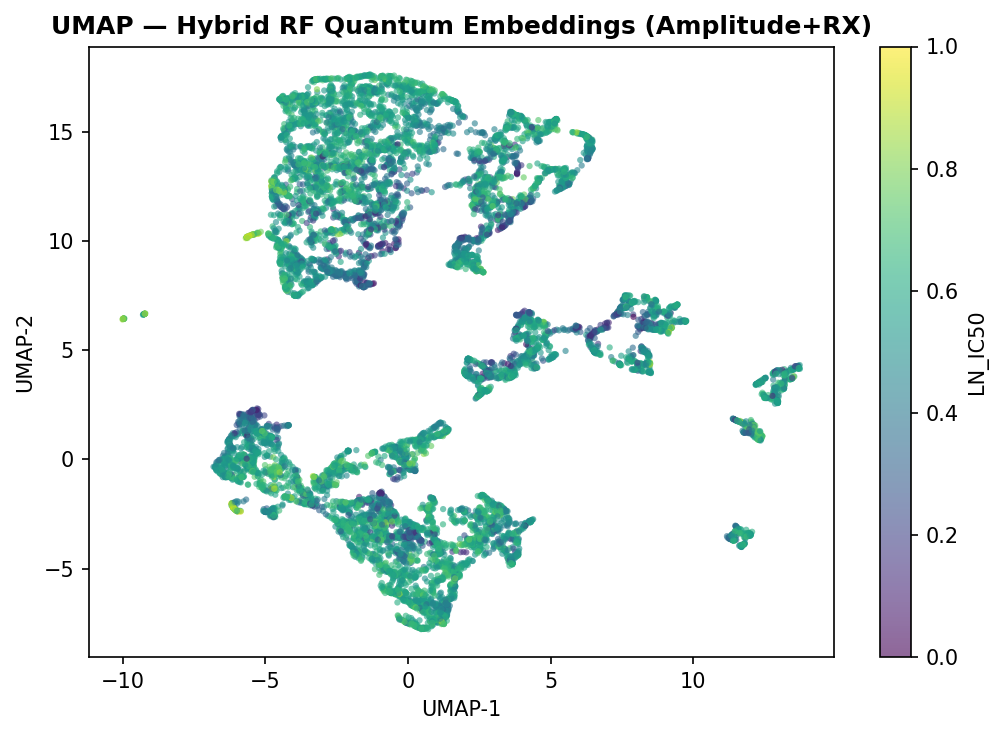

In [ ]:
# ── Cell 15 : UMAP ───────────────────────────────────────────────────
if UMAP_AVAILABLE:
    X_2d = umap.UMAP(n_components=2, random_state=SEED).fit_transform(
        np.vstack([X_train_q, X_val_q]))
    fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
    sc = ax.scatter(X_2d[:,0], X_2d[:,1], c=np.concatenate([Y_train, Y_val]),
                    cmap='viridis', s=9, alpha=0.6, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='LN_IC50')
    ax.set_title('UMAP — Hybrid RF Quantum Embeddings (Amplitude+RX)', fontweight='bold')
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig6_umap.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('UMAP not available.')